# Late Stage Stream 2

## 1. Cai dat va khoi tao moi truong

In [1]:
# Cai dat thu vien can thiet
import subprocess, sys

for pkg in ['ultralytics', 'pandas', 'matplotlib', 'ensemble_boxes']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'Da cai {pkg}')

In [2]:
import os
import gc
import json
import glob
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from pathlib import Path
from collections import Counter

from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion
from torchvision.ops import box_iou

print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CANH BAO: Khong co GPU. Training se rat cham.')

torch 2.11.0+cu128 | CUDA: True
GPU: NVIDIA RTX 6000 Ada Generation


## 2. Cau hinh duong dan va tham so

In [3]:
# === Duong dan tren GPU server ===
BASE_DIR = '/root/AIP491'
RGBT_DATA_DIR = os.path.join(BASE_DIR, 'data', 'RGBTDronePerson')

print(f'Thu muc goc:  {BASE_DIR}')
print(f'Thu muc data: {RGBT_DATA_DIR}')
print(f'Data ton tai: {os.path.exists(RGBT_DATA_DIR)}')

Thu muc goc:  /root/AIP491
Thu muc data: /root/AIP491/data/RGBTDronePerson
Data ton tai: True


In [4]:
# === Backbone pretrained -- Luong 2: LLVIP RGB + LLVIP Thermal ===
RGB_BACKBONE_PATH     = os.path.join(BASE_DIR, 'backbones', 'llvip_rgb_best.pt')
THERMAL_BACKBONE_PATH = os.path.join(BASE_DIR, 'backbones', 'llvip_thermal_best.pt')

LATE_OUTPUT_DIR = os.path.join(BASE_DIR, 'Late-fusion', 'outputs', 'late_luong2')
LATE_YOLO_DIR   = os.path.join(BASE_DIR, 'Late-fusion', 'late_yolo')
os.makedirs(LATE_OUTPUT_DIR, exist_ok=True)
os.makedirs(LATE_YOLO_DIR, exist_ok=True)

SEEDS         = [42, 777, 123]
NUM_EPOCHS    = 50
PATIENCE      = 2
BATCH_SIZE   = 32
IMG_SIZE      = 640
NUM_WORKERS   = 4
WBF_IOU_THR   = 0.55
CLASS_MAP     = {'person': 0, 'rider': 0}

print(f'RGB backbone:     {RGB_BACKBONE_PATH} | ton tai: {os.path.exists(RGB_BACKBONE_PATH)}')
print(f'Thermal backbone: {THERMAL_BACKBONE_PATH} | ton tai: {os.path.exists(THERMAL_BACKBONE_PATH)}')
print(f'Output:           {LATE_OUTPUT_DIR}')
print(f'Seeds:            {SEEDS}')

RGB backbone:     /root/AIP491/backbones/llvip_rgb_best.pt | ton tai: True
Thermal backbone: /root/AIP491/backbones/llvip_thermal_best.pt | ton tai: True
Output:           /root/AIP491/Late-fusion/outputs/late_luong2
Seeds:            [42, 777, 123]


## 3. Phan tich du lieu (EDA)

In [5]:
def parse_voc_xml(xml_path):
    """Doc annotation VOC XML."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    w_img = int(size.find('width').text)
    h_img = int(size.find('height').text)
    objects = []
    for obj in root.findall('object'):
        cls = obj.find('name').text.lower()
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        objects.append((cls, xmin, ymin, xmax, ymax, w_img, h_img))
    return objects


rows = []
for split in ['train', 'val']:
    ann_dir = Path(RGBT_DATA_DIR) / split / 'annotation'
    if not ann_dir.exists():
        print(f'CANH BAO: {ann_dir} khong ton tai')
        continue
    for xml_file in sorted(ann_dir.glob('*.xml')):
        try:
            objs = parse_voc_xml(xml_file)
        except Exception:
            continue
        for cls, xmin, ymin, xmax, ymax, w, h in objs:
            rows.append({
                'split': split, 'stem': xml_file.stem, 'class': cls,
                'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
                'img_w': w, 'img_h': h
            })

df = pd.DataFrame(rows)
print(f'Tong so annotation: {len(df)}')
if len(df) > 0:
    print(df.groupby(['split', 'class']).size().to_string())

Tong so annotation: 70880
split  class    
train  crowd         7172
       person       43169
       rider         4633
       uncertain     1340
val    crowd         2004
       person       11009
       rider         1447
       uncertain      106


## 4. Tien xu ly -- Tao YOLO dataset cho RGB va Thermal rieng

Tao 2 dataset rieng biet: 1 cho RGB (visible/), 1 cho Thermal (thermal/).
Gop nhan `person` va `rider` thanh class 0.

In [6]:
def voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
    cx = (xmin + xmax) / 2.0 / img_w
    cy = (ymin + ymax) / 2.0 / img_h
    w  = (xmax - xmin) / img_w
    h  = (ymax - ymin) / img_h
    return [min(max(v, 0.0), 1.0) for v in [cx, cy, w, h]]


# Kiem tra da convert chua
rgb_labels_dir = os.path.join(LATE_YOLO_DIR, 'rgb', 'labels', 'train')
rgb_labels = list(Path(rgb_labels_dir).glob('*.txt')) if os.path.exists(rgb_labels_dir) else []

if len(rgb_labels) > 0:
    print(f'Du lieu YOLO da ton tai ({len(rgb_labels)} labels). Bo qua buoc convert.')
else:
    for modality in ['rgb', 'thermal']:
        for split in ['train', 'val']:
            os.makedirs(os.path.join(LATE_YOLO_DIR, modality, 'images', split), exist_ok=True)
            os.makedirs(os.path.join(LATE_YOLO_DIR, modality, 'labels', split), exist_ok=True)

    stats = {'converted': 0, 'no_person': 0, 'errors': 0}

    for split in ['train', 'val']:
        ann_dir = Path(RGBT_DATA_DIR) / split / 'annotation'
        vis_dir = Path(RGBT_DATA_DIR) / split / 'visible'
        thr_dir = Path(RGBT_DATA_DIR) / split / 'thermal'

        for xml_file in sorted(ann_dir.glob('*.xml')):
            stem = xml_file.stem
            try:
                objs = parse_voc_xml(xml_file)
            except Exception:
                stats['errors'] += 1
                continue

            person_objs = [o for o in objs if o[0] in CLASS_MAP]
            if not person_objs:
                stats['no_person'] += 1
                continue

            # Labels giong nhau cho ca 2 modality
            label_lines = []
            for cls, xmin, ymin, xmax, ymax, img_w, img_h in person_objs:
                cx, cy, w, h = voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h)
                if w > 0 and h > 0:
                    label_lines.append(f'{CLASS_MAP[cls]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')

            if not label_lines:
                continue

            for modality in ['rgb', 'thermal']:
                lbl_path = os.path.join(LATE_YOLO_DIR, modality, 'labels', split, f'{stem}.txt')
                with open(lbl_path, 'w') as lf:
                    lf.write('\n'.join(label_lines) + '\n')

            # Copy anh
            rgb_src = vis_dir / f'{stem}.jpg'
            thr_src = thr_dir / f'{stem}.jpg'
            rgb_dst = os.path.join(LATE_YOLO_DIR, 'rgb', 'images', split, f'{stem}.jpg')
            thr_dst = os.path.join(LATE_YOLO_DIR, 'thermal', 'images', split, f'{stem}.jpg')

            if rgb_src.exists() and not os.path.exists(rgb_dst):
                shutil.copy2(str(rgb_src), rgb_dst)
            if thr_src.exists() and not os.path.exists(thr_dst):
                shutil.copy2(str(thr_src), thr_dst)

            stats['converted'] += 1

    print(f"Da chuyen doi: {stats['converted']} anh")
    print(f"Khong co person: {stats['no_person']} anh (bo qua)")
    print(f"Loi: {stats['errors']}")

# Thong ke
for mod in ['rgb', 'thermal']:
    for split in ['train', 'val']:
        n_img = len(list(Path(LATE_YOLO_DIR, mod, 'images', split).glob('*.jpg')))
        n_lbl = len(list(Path(LATE_YOLO_DIR, mod, 'labels', split).glob('*.txt')))
        print(f'  {mod}/{split}: images={n_img}, labels={n_lbl}')

Du lieu YOLO da ton tai (4760 labels). Bo qua buoc convert.
  rgb/train: images=4760, labels=4760
  rgb/val: images=1207, labels=1207
  thermal/train: images=4760, labels=4760
  thermal/val: images=1207, labels=1207


## 5. Tao YAML config cho YOLO

In [7]:
# Tao YAML config cho ca 2 modality
for modality in ['rgb', 'thermal']:
    yaml_path = os.path.join(LATE_YOLO_DIR, f'{modality}_data.yaml')
    mod_dir = os.path.join(LATE_YOLO_DIR, modality)
    yaml_content = (
        f'path: {mod_dir}\n'
        'train: images/train\n'
        'val: images/val\n'
        '\n'
        'nc: 1\n'
        "names: ['person']\n"
    )
    with open(yaml_path, 'w') as yf:
        yf.write(yaml_content)
    print(f'Da tao: {yaml_path}')

Da tao: /root/AIP491/Late-fusion/late_yolo/rgb_data.yaml
Da tao: /root/AIP491/Late-fusion/late_yolo/thermal_data.yaml


## 6. Truc quan hoa mau du lieu

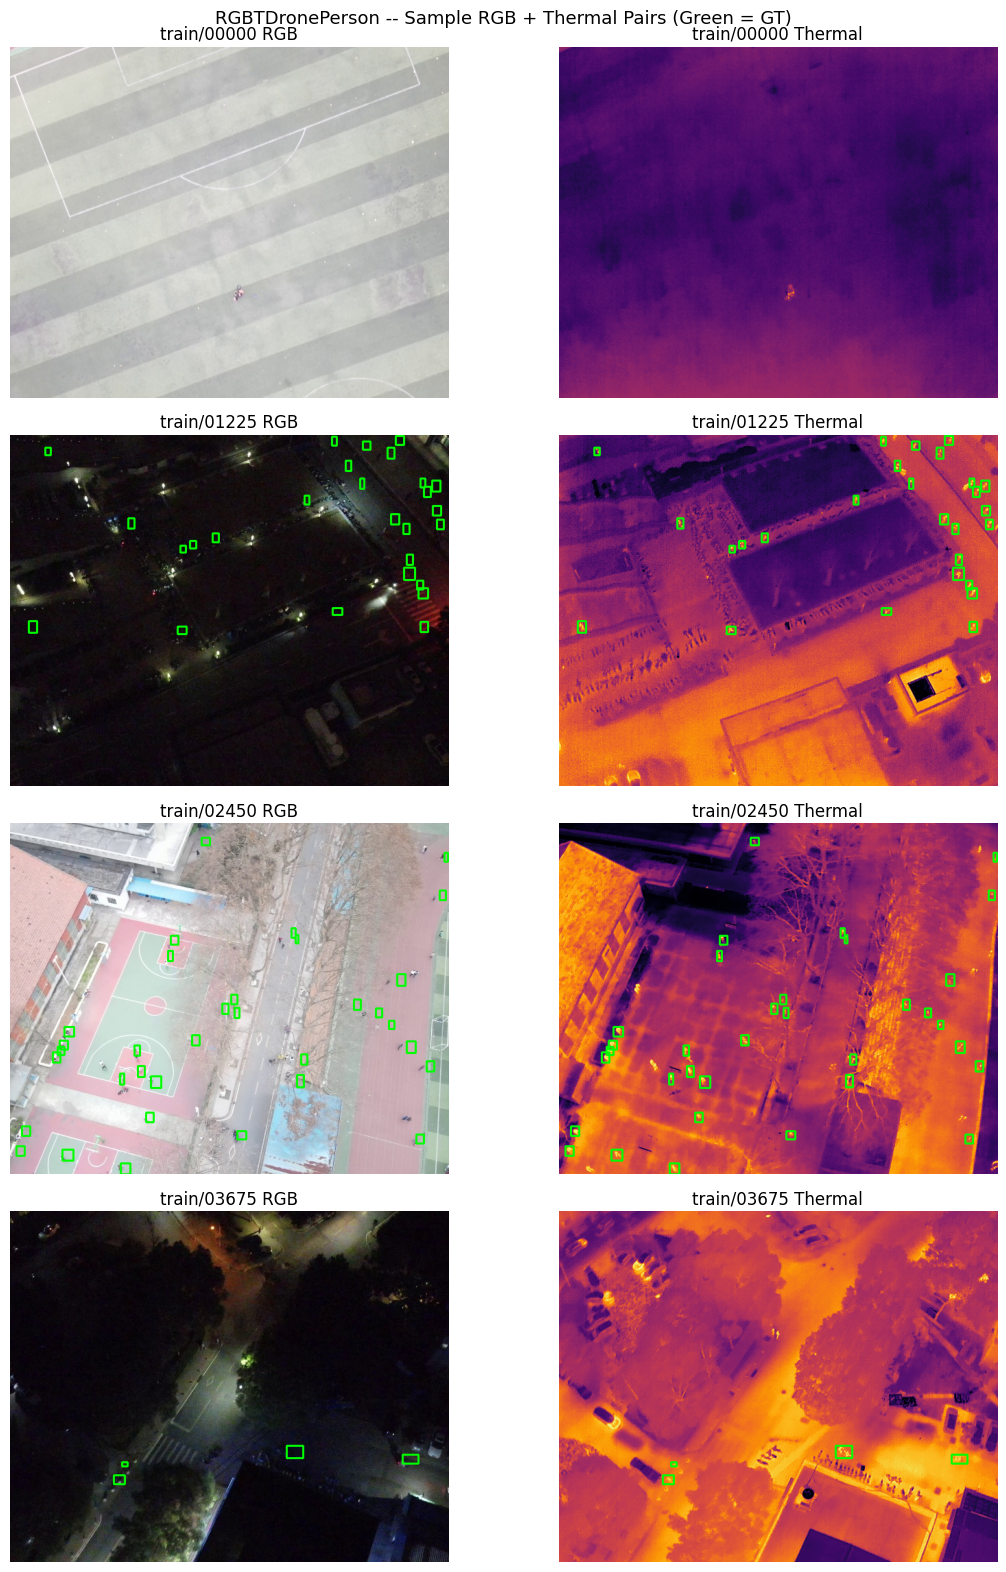

In [8]:
# Hien thi mau cap RGB + Thermal voi GT boxes
sample_stems = []
train_ann_dir = Path(RGBT_DATA_DIR) / 'train' / 'annotation'
if train_ann_dir.exists():
    all_stems = sorted([x.stem for x in train_ann_dir.glob('*.xml')])
    # Lay 4 mau phan bo deu
    step = max(1, len(all_stems) // 4)
    sample_stems = [all_stems[i * step] for i in range(min(4, len(all_stems) // step))]

if not sample_stems:
    print('Khong tim thay du lieu mau.')
else:
    fig, axes = plt.subplots(len(sample_stems), 2, figsize=(12, 4 * len(sample_stems)))
    if len(sample_stems) == 1:
        axes = axes[None, :]

    for row, stem in enumerate(sample_stems):
        found = False
        for split in ['train', 'val']:
            rgb_path = Path(RGBT_DATA_DIR) / split / 'visible' / f'{stem}.jpg'
            thr_path = Path(RGBT_DATA_DIR) / split / 'thermal' / f'{stem}.jpg'
            xml_path = Path(RGBT_DATA_DIR) / split / 'annotation' / f'{stem}.xml'
            if not rgb_path.exists():
                continue
            found = True

            rgb = cv2.cvtColor(cv2.imread(str(rgb_path)), cv2.COLOR_BGR2RGB)
            thr_raw = cv2.imread(str(thr_path), cv2.IMREAD_GRAYSCALE)
            if thr_raw is None:
                thr_raw = np.zeros(rgb.shape[:2], dtype=np.uint8)
            thr_c = cv2.cvtColor(cv2.applyColorMap(thr_raw, cv2.COLORMAP_INFERNO), cv2.COLOR_BGR2RGB)

            if xml_path.exists():
                objs = parse_voc_xml(xml_path)
                for cls, x1, y1, x2, y2, _, _ in objs:
                    if cls in ('person', 'rider'):
                        cv2.rectangle(rgb,   (x1, y1), (x2, y2), (0, 255, 0), 2)
                        cv2.rectangle(thr_c, (x1, y1), (x2, y2), (0, 255, 0), 2)

            axes[row, 0].imshow(rgb);   axes[row, 0].set_title(f'{split}/{stem} RGB');     axes[row, 0].axis('off')
            axes[row, 1].imshow(thr_c); axes[row, 1].set_title(f'{split}/{stem} Thermal'); axes[row, 1].axis('off')
            break
        if not found:
            axes[row, 0].axis('off'); axes[row, 1].axis('off')

    plt.suptitle('RGBTDronePerson -- Sample RGB + Thermal Pairs (Green = GT)', fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Huan luyen RGB va Thermal model rieng biet

Train 2 model YOLO rieng biet cho tung modality, sau do ket hop bang WBF.
Moi seed train lai tu dau voi backbone pretrained.
Resume: neu da co ca 2 checkpoint (rgb best.pt + thermal best.pt) thi bo qua training seed do.

In [9]:
def set_seed(seed):
    """Dat random seed cho reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

In [ ]:
# === Tune hyperparameters cho Late Fusion (chay 1 lan truoc khi train 3 seeds) ===
# Neu da co best_params.json thi bo qua
import os, json as _json
_tune_out = os.path.join(LATE_OUTPUT_DIR, 'tune_best_params.json')

if os.path.exists(_tune_out):
    print(f'Da co tune results: {_tune_out}. Bo qua.')
    with open(_tune_out) as _f:
        _best = _json.load(_f)
    BATCH_SIZE    = _best.get('batch_size', BATCH_SIZE)
    LR0           = _best.get('lr0', 1e-3)
    LRF           = _best.get('lrf', 0.1)
    MOMENTUM      = _best.get('momentum', 0.937)
    WEIGHT_DECAY  = _best.get('weight_decay', 5e-4)
    WARMUP_EPOCHS = _best.get('warmup_epochs', 3)
    print('Best params da ap dung:', _best)
else:
    try:
        import optuna
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
        import optuna

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def _tune_late(trial):
        _lr0    = trial.suggest_float('lr0',          1e-4, 1e-2, log=True)
        _lrf    = trial.suggest_float('lrf',          0.01, 0.3)
        _mom    = trial.suggest_float('momentum',     0.80, 0.98)
        _wd     = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
        _wu     = trial.suggest_int('warmup_epochs',  1, 5)
        _bs     = trial.suggest_categorical('batch_size', [16, 32, 64])

        _rgb_m = YOLO(RGB_BACKBONE_PATH)
        _r = _rgb_m.train(
            data=os.path.join(LATE_YOLO_DIR, 'rgb_data.yaml'),
            epochs=15, imgsz=IMG_SIZE, batch=_bs,
            lr0=_lr0, lrf=_lrf, momentum=_mom, weight_decay=_wd,
            warmup_epochs=_wu, device=DEVICE, workers=NUM_WORKERS,
            patience=0, exist_ok=True, verbose=False,
            project=os.path.join(LATE_OUTPUT_DIR, 'tune'), name='trial_rgb',
        )
        del _rgb_m
        import torch; torch.cuda.empty_cache()

        _thr_m = YOLO(THERMAL_BACKBONE_PATH)
        _t = _thr_m.train(
            data=os.path.join(LATE_YOLO_DIR, 'thermal_data.yaml'),
            epochs=15, imgsz=IMG_SIZE, batch=_bs,
            lr0=_lr0, lrf=_lrf, momentum=_mom, weight_decay=_wd,
            warmup_epochs=_wu, device=DEVICE, workers=NUM_WORKERS,
            patience=0, exist_ok=True, verbose=False,
            project=os.path.join(LATE_OUTPUT_DIR, 'tune'), name='trial_thr',
        )
        del _thr_m
        torch.cuda.empty_cache()

        _map_rgb = _r.results_dict.get('metrics/mAP50-95(B)', 0.0)
        _map_thr = _t.results_dict.get('metrics/mAP50-95(B)', 0.0)
        return (_map_rgb + _map_thr) / 2.0

    _study = optuna.create_study(
        direction='maximize',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5),
        study_name='late_fusion_tune'
    )
    _study.optimize(_tune_late, n_trials=20, show_progress_bar=True)

    _best = dict(_study.best_params)
    _best['best_map'] = _study.best_value
    os.makedirs(LATE_OUTPUT_DIR, exist_ok=True)
    with open(_tune_out, 'w') as _f:
        _json.dump(_best, _f, indent=2)

    BATCH_SIZE    = _best.get('batch_size', BATCH_SIZE)
    LR0           = _best.get('lr0', 1e-3)
    LRF           = _best.get('lrf', 0.1)
    MOMENTUM      = _best.get('momentum', 0.937)
    WEIGHT_DECAY  = _best.get('weight_decay', 5e-4)
    WARMUP_EPOCHS = _best.get('warmup_epochs', 3)

    print('BEST PARAMS:')
    for _k, _v in _best.items():
        print(f'  {_k}: {_v}')


In [11]:
rgb_yaml     = os.path.join(LATE_YOLO_DIR, 'rgb_data.yaml')
thermal_yaml = os.path.join(LATE_YOLO_DIR, 'thermal_data.yaml')

all_results   = {}
all_histories = {}

for seed_idx, SEED in enumerate(SEEDS):
    seed_dir     = os.path.join(LATE_OUTPUT_DIR, f'seed_{SEED}')
    os.makedirs(seed_dir, exist_ok=True)
    results_path = os.path.join(seed_dir, 'late_fusion_results.json')

    rgb_best_chk = os.path.join(seed_dir, 'rgb_train', 'weights', 'best.pt')
    thr_best_chk = os.path.join(seed_dir, 'thermal_train', 'weights', 'best.pt')

    # Resume: da co ket qua eval -> bo qua toan bo
    print(f'\n{"="*60}')
    print(f'  SEED {SEED} ({seed_idx + 1}/{len(SEEDS)})')
    print(f'{"="*60}')

    set_seed(SEED)

    # --- Train RGB model ---
    if os.path.exists(rgb_best_chk):
        print(f'  RGB model da co checkpoint, bo qua training.')
    else:
        print(f'\n  Huan luyen RGB model (backbone: llvip_rgb_best.pt)...')
        rgb_model = YOLO(RGB_BACKBONE_PATH)
        rgb_model.train(
            data=rgb_yaml,
            epochs=NUM_EPOCHS,
            imgsz=IMG_SIZE,
            batch=BATCH_SIZE,
            device=0,
            workers=NUM_WORKERS,
            project=seed_dir,
            name='rgb_train',
            pretrained=True,
            patience=PATIENCE,
            save=True,
            verbose=True,
            seed=SEED,
            exist_ok=True
        )
        del rgb_model
        torch.cuda.empty_cache()
        gc.collect()

    # --- Train Thermal model ---
    if os.path.exists(thr_best_chk):
        print(f'  Thermal model da co checkpoint, bo qua training.')
    else:
        print(f'\n  Huan luyen Thermal model (backbone: llvip_thermal_best.pt)...')
        thr_model = YOLO(THERMAL_BACKBONE_PATH)
        thr_model.train(
            data=thermal_yaml,
            epochs=NUM_EPOCHS,
            imgsz=IMG_SIZE,
            batch=BATCH_SIZE,
            device=0,
            workers=NUM_WORKERS,
            project=seed_dir,
            name='thermal_train',
            pretrained=True,
            patience=PATIENCE,
            save=True,
            verbose=True,
            seed=SEED,
            exist_ok=True
        )
        del thr_model
        torch.cuda.empty_cache()
        gc.collect()

    print(f'  Seed {SEED}: hoan thanh training RGB + Thermal.')

print(f'\nDa hoan thanh huan luyen {len(SEEDS)} seeds.')


  SEED 42 (1/3)

  Huan luyen RGB model (backbone: llvip_rgb_best.pt)...
Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/AIP491/Late-fusion/late_yolo/rgb_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/root/AIP491/backbones/llvip_rgb_best.pt, momentum=0.

## 8. Late Fusion -- Weighted Boxes Fusion (WBF) + Tinh mAP

Ket hop du doan tu RGB model va Thermal model bang WBF.
Tinh mAP COCO 101-point tren VAL SET cua RGBTDronePerson (khong dung YOLO val built-in).

In [12]:
def yolo_result_to_arrays(result):
    """Chuyen YOLO result sang numpy arrays."""
    if result.boxes is None or len(result.boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32), np.array([], dtype=np.float32), np.array([], dtype=np.int32)
    boxes  = result.boxes.xyxy.cpu().numpy().astype(np.float32)
    scores = result.boxes.conf.cpu().numpy().astype(np.float32)
    labels = result.boxes.cls.cpu().numpy().astype(np.int32)
    return boxes, scores, labels


def normalize_boxes(boxes, w, h):
    """Normalize boxes to [0,1]."""
    if len(boxes) == 0:
        return []
    b = boxes.copy()
    b[:, [0, 2]] /= w
    b[:, [1, 3]] /= h
    return np.clip(b, 0, 1).tolist()


def denormalize_boxes(boxes, w, h):
    """Denormalize boxes back to pixel coords."""
    if len(boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    b = np.array(boxes, dtype=np.float32)
    b[:, [0, 2]] *= w
    b[:, [1, 3]] *= h
    return b


def late_fusion_wbf(rgb_model, thermal_model, rgb_path, thermal_path,
                    conf=0.001, iou=0.45, imgsz=640, wbf_iou=0.55):
    """Chay 2 model va ket hop bang WBF."""
    rgb_img = cv2.imread(rgb_path)
    if rgb_img is None:
        return {'fused_boxes': np.zeros((0, 4), dtype=np.float32),
                'fused_scores': np.array([], dtype=np.float32),
                'fused_labels': np.array([], dtype=np.int32),
                'rgb_boxes': np.zeros((0, 4)), 'rgb_scores': np.array([]),
                'thr_boxes': np.zeros((0, 4)), 'thr_scores': np.array([])}
    h, w = rgb_img.shape[:2]

    rgb_result = rgb_model.predict(source=rgb_path, conf=conf, iou=iou,
                                   imgsz=imgsz, verbose=False)[0]
    thr_result = thermal_model.predict(source=thermal_path, conf=conf, iou=iou,
                                       imgsz=imgsz, verbose=False)[0]

    rgb_boxes, rgb_scores, rgb_labels = yolo_result_to_arrays(rgb_result)
    thr_boxes, thr_scores, thr_labels = yolo_result_to_arrays(thr_result)

    boxes_list  = [normalize_boxes(rgb_boxes, w, h), normalize_boxes(thr_boxes, w, h)]
    scores_list = [rgb_scores.tolist(), thr_scores.tolist()]
    labels_list = [rgb_labels.tolist(), thr_labels.tolist()]

    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights=[1, 1], iou_thr=wbf_iou, skip_box_thr=0.0001
    )

    fused_boxes = denormalize_boxes(fused_boxes, w, h)
    return {
        'fused_boxes':  fused_boxes,
        'fused_scores': np.array(fused_scores, dtype=np.float32),
        'fused_labels': np.array(fused_labels, dtype=np.int32),
        'rgb_boxes': rgb_boxes, 'rgb_scores': rgb_scores,
        'thr_boxes': thr_boxes, 'thr_scores': thr_scores
    }


def compute_ap_101(precision_curve, recall_curve):
    """AP COCO 101-point interpolation."""
    mrec = np.concatenate(([0.0], recall_curve, [1.0]))
    mpre = np.concatenate(([1.0], precision_curve, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    recall_points = np.linspace(0, 1, 101)
    ap = 0.0
    for r in recall_points:
        indices = np.where(mrec >= r)[0]
        if len(indices) > 0:
            ap += mpre[indices[0]]
    return ap / 101.0


def load_yolo_label(label_path, img_w, img_h):
    """Doc label YOLO txt, tra ve xyxy boxes."""
    boxes = []
    if not os.path.exists(label_path):
        return np.zeros((0, 4), dtype=np.float32)
    with open(label_path) as lf:
        for line in lf:
            v = list(map(float, line.strip().split()))
            if len(v) == 5:
                cx, cy, bw, bh = v[1], v[2], v[3], v[4]
                x1 = (cx - bw / 2) * img_w
                y1 = (cy - bh / 2) * img_h
                x2 = (cx + bw / 2) * img_w
                y2 = (cy + bh / 2) * img_h
                boxes.append([x1, y1, x2, y2])
    return np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)


def evaluate_late_fusion(rgb_model, thermal_model, rgb_img_dir, thr_img_dir, label_dir,
                          wbf_iou=0.55):
    """Danh gia Late Fusion: P, R, F1, mAP@0.5, mAP@[.5:.95] tren val set."""
    img_paths = sorted(glob.glob(os.path.join(rgb_img_dir, '*.jpg')))
    all_pred_boxes, all_pred_scores, all_gt_boxes, all_img_ids = [], [], [], []
    n_gt_total = 0
    img_id = 0

    for img_path in img_paths:
        stem     = Path(img_path).stem
        thr_path = os.path.join(thr_img_dir, f'{stem}.jpg')
        lbl_path = os.path.join(label_dir, f'{stem}.txt')

        if not os.path.exists(thr_path) or not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        gt = load_yolo_label(lbl_path, w, h)
        n_gt_total += len(gt)
        all_gt_boxes.append(gt)

        out = late_fusion_wbf(rgb_model, thermal_model, img_path, thr_path, wbf_iou=wbf_iou)
        for i in range(len(out['fused_boxes'])):
            all_pred_boxes.append(out['fused_boxes'][i])
            all_pred_scores.append(float(out['fused_scores'][i]))
            all_img_ids.append(img_id)
        img_id += 1

    if n_gt_total == 0:
        print('Khong tim thay ground truth!')
        return {}

    all_pred_scores_np = np.array(all_pred_scores, dtype=np.float32)
    all_img_ids_np     = np.array(all_img_ids, dtype=np.int32)
    sorted_indices     = np.argsort(-all_pred_scores_np)

    iou_thresholds = np.arange(0.5, 1.0, 0.05)
    ap_per_iou = {}

    for iou_thresh in iou_thresholds:
        matched_gt = {i: set() for i in range(len(all_gt_boxes))}
        tp = np.zeros(len(sorted_indices))
        fp = np.zeros(len(sorted_indices))

        for rank, det_idx in enumerate(sorted_indices):
            img_id_val = int(all_img_ids_np[det_idx])
            pred_box   = torch.tensor([all_pred_boxes[det_idx]])
            gt_boxes   = all_gt_boxes[img_id_val]
            if len(gt_boxes) == 0:
                fp[rank] = 1
                continue
            ious      = box_iou(pred_box, torch.tensor(gt_boxes))[0].numpy()
            max_iou   = ious.max()
            max_gt_idx = int(ious.argmax())
            if max_iou >= iou_thresh and max_gt_idx not in matched_gt[img_id_val]:
                tp[rank] = 1
                matched_gt[img_id_val].add(max_gt_idx)
            else:
                fp[rank] = 1

        cum_tp     = np.cumsum(tp)
        cum_fp     = np.cumsum(fp)
        prec_curve = cum_tp / (cum_tp + cum_fp + 1e-6)
        rec_curve  = cum_tp / (n_gt_total + 1e-6)
        ap = compute_ap_101(prec_curve, rec_curve)
        ap_per_iou[f'{iou_thresh:.2f}'] = float(ap)

    map50    = ap_per_iou.get('0.50', 0.0)
    map50_95 = float(np.mean(list(ap_per_iou.values())))

    # P/R/F1 tai conf >= 0.25, IoU >= 0.5
    conf_mask = all_pred_scores_np[sorted_indices] >= 0.25
    tp_025, fp_025 = 0, 0
    matched_025 = {i: set() for i in range(len(all_gt_boxes))}
    for rank in range(len(sorted_indices)):
        if not conf_mask[rank]:
            break
        det_idx    = sorted_indices[rank]
        img_id_val = int(all_img_ids_np[det_idx])
        pred_box   = torch.tensor([all_pred_boxes[det_idx]])
        gt_boxes   = all_gt_boxes[img_id_val]
        if len(gt_boxes) == 0:
            fp_025 += 1
            continue
        ious       = box_iou(pred_box, torch.tensor(gt_boxes))[0].numpy()
        max_iou    = ious.max()
        max_gt_idx = int(ious.argmax())
        if max_iou >= 0.5 and max_gt_idx not in matched_025[img_id_val]:
            tp_025 += 1
            matched_025[img_id_val].add(max_gt_idx)
        else:
            fp_025 += 1

    fn_025    = n_gt_total - tp_025
    precision = tp_025 / (tp_025 + fp_025 + 1e-9)
    recall    = tp_025 / (tp_025 + fn_025 + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        'precision': float(precision), 'recall': float(recall), 'f1': float(f1),
        'map50': float(map50), 'map50_95': float(map50_95),
        'ap_per_iou': ap_per_iou
    }

In [13]:
rgb_img_val = os.path.join(LATE_YOLO_DIR, 'rgb', 'images', 'val')
thr_img_val = os.path.join(LATE_YOLO_DIR, 'thermal', 'images', 'val')
label_val   = os.path.join(LATE_YOLO_DIR, 'rgb', 'labels', 'val')

for SEED in SEEDS:
    seed_dir = os.path.join(LATE_OUTPUT_DIR, f'seed_{SEED}')
    rgb_best = os.path.join(seed_dir, 'rgb_train', 'weights', 'best.pt')
    thr_best = os.path.join(seed_dir, 'thermal_train', 'weights', 'best.pt')

    if not os.path.exists(rgb_best) or not os.path.exists(thr_best):
        print(
        f'Seed {SEED}: thieu checkpoint '
        f'(rgb={os.path.exists(rgb_best)}, '
        f'thr={os.path.exists(thr_best)}), bo qua.'
        )
        continue

    print(f'\nDanh gia Late Fusion seed {SEED}...')
    rgb_model     = YOLO(rgb_best)
    thermal_model = YOLO(thr_best)

    metrics = evaluate_late_fusion(
        rgb_model, thermal_model,
        rgb_img_val, thr_img_val, label_val,
        wbf_iou=WBF_IOU_THR
    )
    all_results[SEED] = metrics

    results_path = os.path.join(seed_dir, 'late_fusion_results.json')
    with open(results_path, 'w') as rf:
        json.dump(metrics, rf, indent=2)

    print(f'  Precision:      {metrics["precision"]:.4f}')
    print(f'  Recall:         {metrics["recall"]:.4f}')
    print(f'  F1:             {metrics["f1"]:.4f}')
    print(f'  mAP@0.5:        {metrics["map50"]:.4f}')
    print(f'  mAP@[.5:.95]:   {metrics["map50_95"]:.4f}')

    del rgb_model, thermal_model
    torch.cuda.empty_cache()
    gc.collect()


Danh gia Late Fusion seed 42...


/tmp/ipykernel_4453/469019861.py:152: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  pred_box   = torch.tensor([all_pred_boxes[det_idx]])


  Precision:      0.8391
  Recall:         0.1219
  F1:             0.2128
  mAP@0.5:        0.5220
  mAP@[.5:.95]:   0.1778

Danh gia Late Fusion seed 777...
  Precision:      0.8391
  Recall:         0.1219
  F1:             0.2128
  mAP@0.5:        0.5220
  mAP@[.5:.95]:   0.1778

Danh gia Late Fusion seed 123...
  Precision:      0.8391
  Recall:         0.1219
  F1:             0.2128
  mAP@0.5:        0.5220
  mAP@[.5:.95]:   0.1778


## 9. Bang tong hop ket qua

In [14]:
print(f'\n{"="*70}')
print(f'  BANG TONG HOP -- Late Fusion Luong 2 (LLVIP (RGB) + LLVIP (Thermal))')
print(f'{"="*70}')
print(f'{"Seed":<8} {"Precision":>10} {"Recall":>10} {"F1":>10} {"mAP@0.5":>10} {"mAP@[.5:.95]":>14}')
print(f'{"="*62}')

for seed in SEEDS:
    if seed in all_results:
        m = all_results[seed]
        print(f' {seed:<7} {m["precision"]:>10.4f} {m["recall"]:>10.4f} {m["f1"]:>10.4f} '
              f'{m["map50"]:>10.4f} {m["map50_95"]:>14.4f}')

if len(all_results) >= 2:
    print(f'{"-"*62}')
    for metric_name, key in [('Precision', 'precision'), ('Recall', 'recall'), ('F1', 'f1'),
                              ('mAP@0.5', 'map50'), ('mAP@[.5:.95]', 'map50_95')]:
        vals = [all_results[s][key] for s in SEEDS if s in all_results]
        print(f'  {metric_name:<14}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}')
print(f'{"="*70}')


  BANG TONG HOP -- Late Fusion Luong 2 (LLVIP (RGB) + LLVIP (Thermal))
Seed      Precision     Recall         F1    mAP@0.5   mAP@[.5:.95]
 42          0.8391     0.1219     0.2128     0.5220         0.1778
 777         0.8391     0.1219     0.2128     0.5220         0.1778
 123         0.8391     0.1219     0.2128     0.5220         0.1778
--------------------------------------------------------------
  Precision     : 0.8391 +/- 0.0000
  Recall        : 0.1219 +/- 0.0000
  F1            : 0.2128 +/- 0.0000
  mAP@0.5       : 0.5220 +/- 0.0000
  mAP@[.5:.95]  : 0.1778 +/- 0.0000


## 10. Bieu do Loss (tu YOLO training)

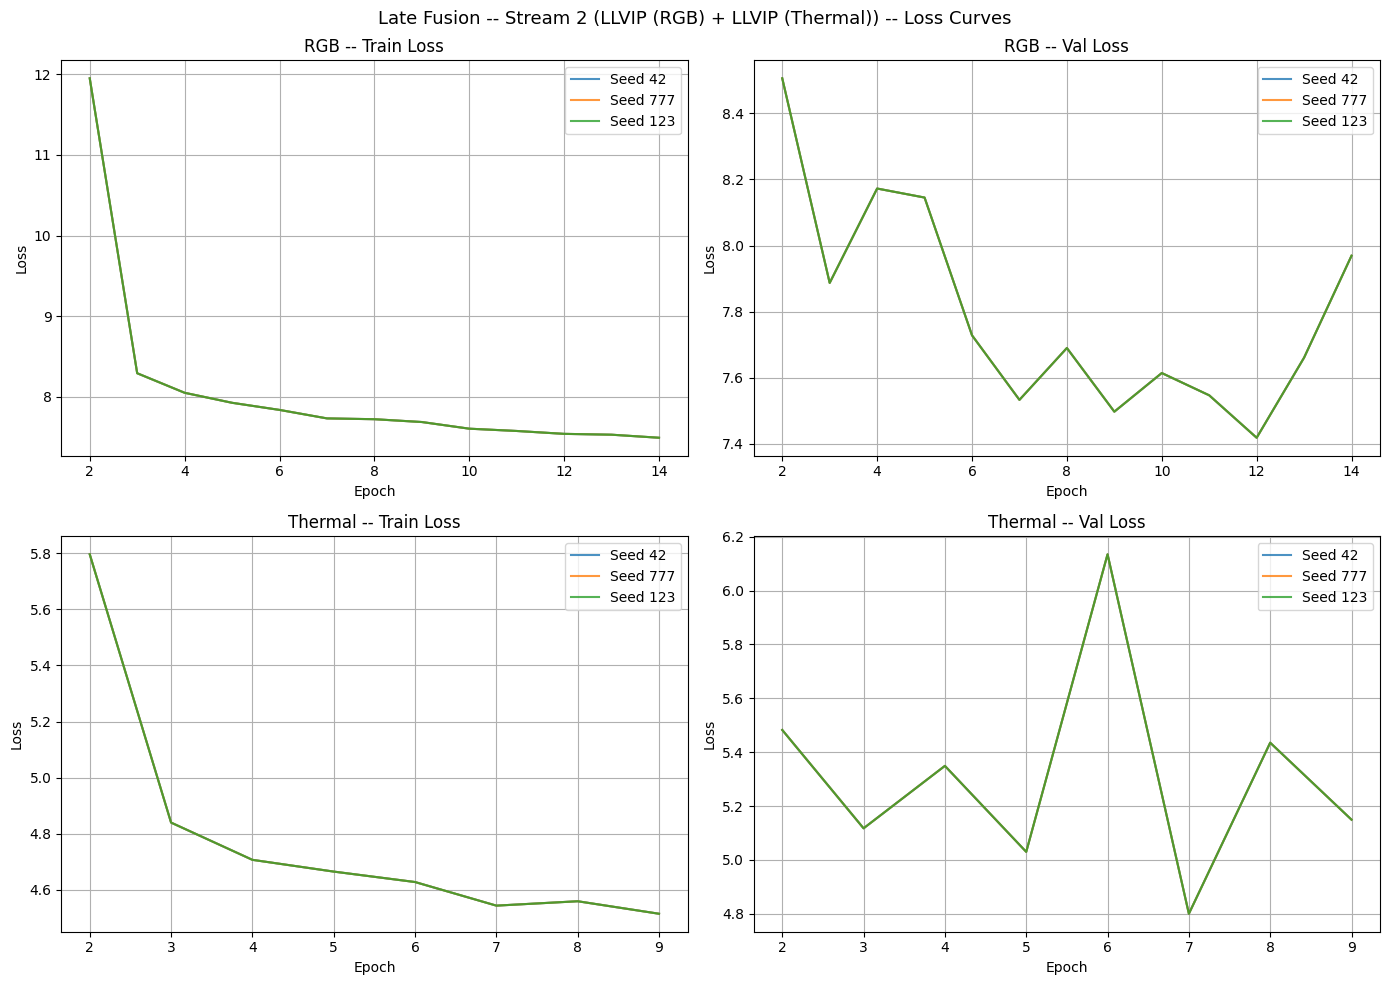

In [15]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, SEED in enumerate(SEEDS):
    seed_dir = os.path.join(LATE_OUTPUT_DIR, f'seed_{SEED}')

    for mod_idx, (mod_name, run_name) in enumerate([('RGB', 'rgb_train'), ('Thermal', 'thermal_train')]):
        csv_path = os.path.join(seed_dir, run_name, 'results.csv')
        if not os.path.exists(csv_path):
            continue
        df_res = pd.read_csv(csv_path)
        df_res.columns = [c.strip() for c in df_res.columns]

        ep = df_res['epoch'] + 1 if 'epoch' in df_res.columns else range(1, len(df_res) + 1)

        if 'train/box_loss' in df_res.columns:
            total_train = df_res['train/box_loss'] + df_res['train/cls_loss'] + df_res['train/dfl_loss']
            axes[mod_idx, 0].plot(ep, total_train, color=colors[i], alpha=0.8, label=f'Seed {SEED}')

        if 'val/box_loss' in df_res.columns:
            total_val = df_res['val/box_loss'] + df_res['val/cls_loss'] + df_res['val/dfl_loss']
            axes[mod_idx, 1].plot(ep, total_val, color=colors[i], alpha=0.8, label=f'Seed {SEED}')

axes[0, 0].set(title='RGB -- Train Loss', xlabel='Epoch', ylabel='Loss'); axes[0, 0].legend(); axes[0, 0].grid(True)
axes[0, 1].set(title='RGB -- Val Loss',   xlabel='Epoch', ylabel='Loss'); axes[0, 1].legend(); axes[0, 1].grid(True)
axes[1, 0].set(title='Thermal -- Train Loss', xlabel='Epoch', ylabel='Loss'); axes[1, 0].legend(); axes[1, 0].grid(True)
axes[1, 1].set(title='Thermal -- Val Loss',   xlabel='Epoch', ylabel='Loss'); axes[1, 1].legend(); axes[1, 1].grid(True)

plt.suptitle('Late Fusion -- Stream 2 (LLVIP (RGB) + LLVIP (Thermal)) -- Loss Curves', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(LATE_OUTPUT_DIR, 'loss_curves_all_seeds.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Luu ket qua cuoi cung

In [ ]:
import csv

csv_path = os.path.join(LATE_OUTPUT_DIR, 'metrics_summary.csv')
with open(csv_path, 'w', newline='') as cf:
    writer = csv.writer(cf)
    writer.writerow(['Seed', 'Precision', 'Recall', 'F1', 'mAP@0.5', 'mAP@[.5:.95]'])
    for seed in SEEDS:
        if seed in all_results:
            m = all_results[seed]
            writer.writerow([seed,
                             f'{m["precision"]:.4f}', f'{m["recall"]:.4f}',
                             f'{m["f1"]:.4f}',        f'{m["map50"]:.4f}',
                             f'{m["map50_95"]:.4f}'])
    if len(all_results) >= 2:
        means = {k: np.mean([all_results[s][k] for s in SEEDS if s in all_results])
                 for k in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
        stds  = {k: np.std([all_results[s][k] for s in SEEDS if s in all_results])
                 for k in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
        writer.writerow(['Mean',
                         f'{means["precision"]:.4f}', f'{means["recall"]:.4f}',
                         f'{means["f1"]:.4f}',        f'{means["map50"]:.4f}',
                         f'{means["map50_95"]:.4f}'])
        writer.writerow(['Std',
                         f'{stds["precision"]:.4f}', f'{stds["recall"]:.4f}',
                         f'{stds["f1"]:.4f}',        f'{stds["map50"]:.4f}',
                         f'{stds["map50_95"]:.4f}'])

print(f'Da luu metrics tai: {csv_path}')
print('\nHoan thanh -- Late Fusion Luong 2.')